#Proyecto Deep-Learning

## Parte 1//Datos Tubulares

In [158]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torch.optim import Adam
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [159]:

t_df = pd.read_csv('/content/HAM10000_metadata.csv', sep=',')
t_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [160]:
#Miramos los tipos de cada columna
t_df.dtypes
t_df = t_df.drop(['lesion_id', 'image_id'], axis=1 )

In [161]:
pd.crosstab(t_df['dx_type'], t_df['dx'], normalize='index')
# Gran posibilidad de data leakage con variable dx_type

dx,akiec,bcc,bkl,df,mel,nv,vasc
dx_type,,,,,,,
confocal,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000
consensus,0.000000,0.000000,0.292683,0.066519,0.000000,0.55765,0.083149
follow_up,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000
histo,0.061236,0.096255,0.143446,0.010300,0.208427,0.46779,0.012547


In [162]:
t_df = t_df.drop(['dx_type'], axis=1)

In [163]:
print(t_df.columns)

Index(['dx', 'age', 'sex', 'localization'], dtype='object')


In [164]:
#Vamos a comenzar con los datos tubulares
#Separamos objetivo y variables
y_tub = t_df['dx']#Variable objetivo
X_tub = t_df.drop(columns= ['dx'])
print('Tamaño de nuestra tabla es de {}'.format(X_tub.shape))
print('Tamaño de el vector objetivo es de {}'.format(y_tub.shape))
X_train, X_test, y_train, y_test = train_test_split(X_tub, y_tub, test_size=0.2, shuffle= True, stratify=y_tub, random_state=42 )

Tamaño de nuestra tabla es de (10015, 3)
Tamaño de el vector objetivo es de (10015,)


In [165]:
X_train.dtypes

,0
age,float64
sex,object
localization,object


In [166]:
cat_columns = ['sex', 'localization']
num_columns = ['age']

In [167]:
for col in X_train.columns:
  print('\n {}'.format(col))
  print(X_train[col].value_counts())


 age
age
45.0    1063
50.0     931
55.0     844
40.0     789
60.0     650
70.0     599
35.0     588
65.0     578
75.0     474
30.0     367
80.0     331
85.0     236
25.0     201
20.0     123
5.0       66
15.0      64
10.0      34
0.0       30
Name: count, dtype: int64

 sex
sex
male       4320
female     3648
unknown      44
Name: count, dtype: int64

 localization
localization
back               1765
lower extremity    1631
trunk              1136
upper extremity     883
abdomen             808
face                604
chest               321
foot                271
unknown             187
neck                136
scalp               105
hand                 72
ear                  46
genital              41
acral                 6
Name: count, dtype: int64


In [168]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
#Vamos a procesar nuestras variables
preprocessor = ColumnTransformer(
   transformers= [
       ( 'cat',
        Pipeline(
            steps=[
                ('onehot', OneHotEncoder(handle_unknown= 'ignore', sparse_output= False))
            ]
        ),cat_columns

       ),
       ('num',
        Pipeline(
            steps= [
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler() )
            ]
        ), num_columns

       )
   ]

)
Xtr_proc = preprocessor.fit_transform(X_train).astype('float32')
Xts_proc = preprocessor.transform(X_test).astype('float32')

In [169]:
from sklearn.preprocessing import LabelEncoder
#Le damos labels a nuestra variable objetivo
le = LabelEncoder()
ytr_pr = le.fit_transform(y_train)
yts_pr = le.transform(y_test)

In [170]:
#Partimos otra vez el dataset de train para crear la validación
Xtr_pr,Xvl_pr, ytr_pr,yvl_pr = train_test_split(Xtr_proc, ytr_pr,test_size= 0.15, shuffle = True, stratify= ytr_pr, random_state=42)


In [171]:
print(type(Xtr_proc))

<class 'numpy.ndarray'>


In [172]:
'''Transformamos los datos que tenemos en tensores, dado
que ya transformamos los features a el tipo float32, no
hace falta cambiarlos de nuevo'''

Xtr_pr = torch.tensor(Xtr_pr)
ytr_pr = torch.tensor(ytr_pr, dtype= torch.long)

Xvl_pr =torch.tensor(Xvl_pr)
yvl_pr = torch.tensor(yvl_pr, dtype= torch.long)


Xts_pr =torch.tensor(Xts_proc)
yts_pr = torch.tensor(yts_pr, dtype= torch.long)


In [173]:
#Hiperparameters
EPOCH = 50
BATCH_S = 48
LR = 0.0001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [174]:
'''
Dado que me llevan dando problemas de accuracy con el módelo,
voy a probar WeightsRandom. El problema en si es que una de las clases
es tiene una mayor representación al resto. Podemos verlos con la siguiente
función.
Update, el problema estaba en un par de nan sueltos en la columna 'age'
'''
print( np.bincount(ytr_pr))

[ 223  349  747   78  757 4559   97]


In [175]:
class_counts = np.bincount(ytr_pr)
weights = 1.0 / class_counts
weights = weights / weights.sum()

weights = torch.tensor(weights, dtype=torch.float32)
sample_weights = weights[ytr_pr]
sampler = WeightedRandomSampler(sample_weights,len(sample_weights))


In [176]:
sample_weights

tensor([0.3090, 0.0401, 0.0066,  ..., 0.0396, 0.0066, 0.0066])

In [177]:
#Separamos los datasets en batches
train_dataset = TensorDataset(Xtr_pr, ytr_pr)
train_loader = DataLoader(train_dataset, batch_size= BATCH_S, sampler = sampler)

val_dataset = TensorDataset(Xvl_pr, yvl_pr)
val_loader = DataLoader(val_dataset, batch_size= BATCH_S, shuffle=False)

test_dataset = TensorDataset(Xts_pr, yts_pr)
test_loader = DataLoader(test_dataset, batch_size= BATCH_S, shuffle=False)

In [178]:
#Creamos el modelo
class TubularModel(nn.Module):
  def __init__(self, input_size=Xtr_pr.shape[1], num_classes = 7):
    super(TubularModel, self).__init__()
    self.l1 = nn.Linear(input_size,64)
    self.btch1 = nn.BatchNorm1d(64)
    self.relu = nn.ReLU()
    self.l2 = nn.Linear(64,32)
    self.btch2 = nn.BatchNorm1d(32)

    self.l3 = nn.Linear(32, num_classes)

  def forward(self, x):
    x = self.relu(self.btch1(self.l1(x)))
    x = self.relu(self.btch2(self.l2(x)))
    x = self.l3(x)
    return x

  def forward_features(self, x):
    x = self.relu(self.btch1(self.l1(x)))
    x = self.relu(self.btch2(self.l2(x)))
    return x




In [179]:
model_tb = TubularModel()
#model_tb = model_tb.cuda()
model_tb = model_tb.to(device)
model_tb.train()

TubularModel(
  (l1): Linear(in_features=19, out_features=64, bias=True)
  (btch1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (l2): Linear(in_features=64, out_features=32, bias=True)
  (btch2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (l3): Linear(in_features=32, out_features=7, bias=True)
)

In [180]:
#Definimos nuestra funcion de coste y nuestro optimizador
loss_fn = nn.CrossEntropyLoss()
optmzr = Adam(model_tb.parameters(), lr= LR)

In [181]:
def train_bf(model, epochs,l_func, optimizer, loader):
  '''
  Bucle de entrenamiento para modelo tubular y modelo imagen
  '''
  for epoch in range(epochs):
    correct = 0
    total = 0
    total_loss = 0
    for X_b, y_b in tqdm(loader):
      #X_b, y_b = X_b.cuda(), y_b.cuda()
      X_b, y_b = X_b.to(device), y_b.to(device)
      optimizer.zero_grad()
      model_pred = model(X_b)
      loss = l_func(model_pred,y_b)

      loss.backward()
      optimizer.step()
      preds = torch.max(model_pred, 1)[1]

      correct += (preds == y_b).sum().item()
      total += y_b.shape[0]
      total_loss += loss.item()
    acc = 100 * correct/total
    avg_loss = total_loss / len(loader)
    print(f'Para las epoca: {epoch}, el accuracy es de {acc}.2f')
  return acc, avg_loss



In [182]:
train_bf(model_tb,EPOCH,loss_fn, optmzr,train_loader)

100%|██████████| 142/142 [00:00<00:00, 395.04it/s]


Para las epoca: 0, el accuracy es de 23.729809104258443.2f


100%|██████████| 142/142 [00:00<00:00, 431.62it/s]


Para las epoca: 1, el accuracy es de 26.94566813509545.2f


100%|██████████| 142/142 [00:00<00:00, 410.84it/s]


...

100%|██████████| 142/142 [00:00<00:00, 299.52it/s]


Para las epoca: 48, el accuracy es de 42.59911894273128.2f


100%|██████████| 142/142 [00:00<00:00, 312.44it/s]

Para las epoca: 49, el accuracy es de 42.584434654919235.2f


(42.584434654919235, 1.4397435372983907)

In [183]:
def evaluate(model, loader, l_func):
  """
  Función de evaluación para modelo tubular y modelo imagen (CV)
  """
  correct = 0
  total = 0

  model.eval()
  with torch.no_grad():
    for X_b, y_b in loader:
      #X_b, y_b = X_b.cuda(), y_b.cuda()
      X_b, y_b = X_b.to(device), y_b.to(device)
      model_pred = model(X_b)
      _, predicted = torch.max(model_pred,1)
      total += y_b.size(0)
      correct += (predicted == y_b).sum().item()

  acc = 100 * correct/total
  print(f'Accuracy: {acc}')
  return acc



In [184]:
evaluate(model_tb,val_loader,loss_fn)

Accuracy: 30.199667221297837


30.199667221297837

In [185]:
evaluate(model_tb,test_loader,loss_fn)

Accuracy: 28.05791313030454


28.05791313030454

##Parte 2//

In [186]:
i_df= pd.read_csv('/content/hmnist_28_28_L.csv', sep=',')
Xi = i_df.drop(['label'], axis=1)
Xi = Xi / 255.0
Xi = Xi.to_numpy()
yi = i_df['label']
yi = yi.to_numpy()

In [187]:
Xi = torch.tensor(Xi, dtype = torch.float32)
Xi = Xi.reshape(-1,1,28,28)
yi = torch.tensor(yi, dtype =torch.long)

In [188]:
#Hacemos las particiones
Xi_tr, Xi_ts, yi_tr, yi_ts = train_test_split(Xi, yi, test_size= 0.2, stratify=yi,random_state=42)
Xi_tr, Xi_vl, yi_tr, yi_vl = train_test_split(Xi_tr,yi_tr, test_size=0.15, stratify= yi_tr, random_state=42)

In [189]:
#Hiperparameters
EPOCH = 20
BATCH_S = 48
LR = 0.0005

In [190]:
train_dataseti = TensorDataset(Xi_tr, yi_tr)
train_loaderi = DataLoader(train_dataseti, batch_size= BATCH_S, shuffle=True)
validation_dataseti = TensorDataset(Xi_vl, yi_vl)
val_loaderi = DataLoader(validation_dataseti, batch_size= BATCH_S, shuffle=False)
test_dataseti = TensorDataset(Xi_ts, yi_ts)
test_loaderi = DataLoader(test_dataseti, batch_size= BATCH_S, shuffle=False)

In [191]:
class ImgModel(nn.Module):
  def __init__(self, input_size= 28*28, num_classes = 7):
    super(ImgModel, self).__init__()

    self.flatten = nn.Flatten()
    self.relu = nn.ReLU()
    self.drop = nn.Dropout(0.3)

    self.l1 = nn.Linear(input_size, 128)
    self.l2 = nn.Linear(128,64)
    self.l3 = nn.Linear(64,7)

  def forward(self,x):

    x = self.flatten(x)
    x = self.drop(self.relu(self.l1(x)))
    x = self.drop(self.relu(self.l2(x)))
    x = self.l3(x)
    return x

  def forward_features(self,x):

    x = self.flatten(x)
    x = self.drop(self.relu(self.l1(x)))
    x = self.drop(self.relu(self.l2(x)))
    return x


In [192]:
model_im = ImgModel()
model_im = model_im.to(device)
optmzr_i = Adam(model_im.parameters(), lr= LR)

In [193]:
model_im.train()

ImgModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (relu): ReLU()
  (drop): Dropout(p=0.3, inplace=False)
  (l1): Linear(in_features=784, out_features=128, bias=True)
  (l2): Linear(in_features=128, out_features=64, bias=True)
  (l3): Linear(in_features=64, out_features=7, bias=True)
)

In [194]:
train_bf(model_im, EPOCH, loss_fn, optmzr_i, train_loaderi)

100%|██████████| 142/142 [00:00<00:00, 342.16it/s]


Para las epoca: 0, el accuracy es de 65.87371512481644.2f


100%|██████████| 142/142 [00:00<00:00, 442.22it/s]


Para las epoca: 1, el accuracy es de 66.94566813509545.2f


100%|██████████| 142/142 [00:00<00:00, 425.24it/s]


...

100%|██████████| 142/142 [00:00<00:00, 421.97it/s]


Para las epoca: 18, el accuracy es de 66.91629955947137.2f


100%|██████████| 142/142 [00:00<00:00, 437.97it/s]

Para las epoca: 19, el accuracy es de 67.01908957415566.2f


(67.01908957415566, 1.0431787371635437)

In [195]:
evaluate(model_im,val_loaderi,loss_fn)

Accuracy: 66.97171381031615


66.97171381031615

In [196]:
evaluate(model_im, test_loaderi,loss_fn)

Accuracy: 66.94957563654518


66.94957563654518

##Parte 3// Late fusion

In [197]:
#Creamos el dataset y el dataloader fusionado
train_datasetlf = TensorDataset(Xtr_pr, Xi_tr, ytr_pr)
train_loaderlf = DataLoader(train_datasetlf, batch_size=32, shuffle=True)

val_datasetlf = TensorDataset(Xvl_pr, Xi_vl, yvl_pr)
val_loaderlf = DataLoader(val_datasetlf, batch_size=32, shuffle=False)

test_datasetlf = TensorDataset(Xts_pr, Xi_ts, yts_pr)
test_loaderlf = DataLoader(test_datasetlf, batch_size=32, shuffle=False)

In [198]:
for x_tab, x_img, y in train_loaderlf:
    print(x_tab.shape)
    print(x_img.shape)
    print(y.shape)
    break

torch.Size([32, 19])
torch.Size([32, 1, 28, 28])
torch.Size([32])


In [199]:
class LateFusionModel(nn.Module):
  def __init__(self, model_tb, model_im):
    super(LateFusionModel,self).__init__()
    self.tb = model_tb
    self.img = model_im

  def forward(self, x_tab, x_img):

    x_tab = self.tb(x_tab)
    x_img = self.img(x_img)

    x_fus = (x_tab + x_img)/ 2

    return x_fus


In [200]:
model_lf = LateFusionModel(model_tb,model_im).to(device)
optmzr_lf = Adam(model_lf.parameters(), lr=LR)

In [201]:
model_lf.train()

LateFusionModel(
  (tb): TubularModel(
    (l1): Linear(in_features=19, out_features=64, bias=True)
    (btch1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (l2): Linear(in_features=64, out_features=32, bias=True)
    (btch2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (l3): Linear(in_features=32, out_features=7, bias=True)
  )
  (img): ImgModel(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (relu): ReLU()
    (drop): Dropout(p=0.3, inplace=False)
    (l1): Linear(in_features=784, out_features=128, bias=True)
    (l2): Linear(in_features=128, out_features=64, bias=True)
    (l3): Linear(in_features=64, out_features=7, bias=True)
  )
)

In [202]:
def train_lf(model,loader,epochs,optimizer, l_func):
  '''
  Función de entrenamiento para clases multimodales
  '''
  for epoch in range(epochs):
    total = 0
    correct = 0
    total_loss = 0
    for xt_b, xi_b, y_b in tqdm(loader):
      xt_b, xi_b, y_b = xt_b.to(device), xi_b.to(device) , y_b.to(device)

      optimizer.zero_grad()
      model_pred = model(xt_b,xi_b)
      loss = l_func(model_pred,y_b)

      loss.backward()
      optimizer.step()
      preds = torch.max(model_pred, 1)[1]

      correct += (preds == y_b).sum().item()
      total += y_b.shape[0]
      total_loss += loss.item()

    acc = 100 * correct/total
    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch} | Loss: {avg_loss:.4f} | Acc: {acc:.4f}")
  return acc,  avg_loss


In [203]:
train_lf(model_lf,train_loaderlf,EPOCH,optmzr_lf,loss_fn)

100%|██████████| 213/213 [00:00<00:00, 294.14it/s]


Epoch 0 | Loss: 1.1709 | Acc: 59.8972


100%|██████████| 213/213 [00:00<00:00, 302.56it/s]


Epoch 1 | Loss: 0.9516 | Acc: 68.9574


100%|██████████| 213/213 [00:00<00:00, 309.74it/s]


...

100%|██████████| 213/213 [00:00<00:00, 296.31it/s]


Epoch 18 | Loss: 0.8814 | Acc: 70.1322


100%|██████████| 213/213 [00:00<00:00, 299.67it/s]


Epoch 19 | Loss: 0.8812 | Acc: 69.8825


(69.88252569750367, 0.8811512099745128)

In [204]:
for  xt_b, xi_b, y_b in train_loaderlf:
  print(xt_b.shape)
  print(xi_b.shape)
  print(y_b.shape)
  break

torch.Size([32, 19])
torch.Size([32, 1, 28, 28])
torch.Size([32])


In [205]:
def evaluate_lf(model, loader, l_func):
  """
  Fúncion de test y validación para clases multimodales
  """
  correct = 0
  total = 0

  model.eval()
  with torch.no_grad():
    for xt_b, xi_b, y_b in loader:
      xt_b, xi_b, y_b = xt_b.to(device), xi_b.to(device), y_b.to(device)

      model_pred = model(xt_b, xi_b)
      _, predicted = torch.max(model_pred, 1)

      total += y_b.size(0)
      correct += (predicted == y_b).sum().item()

    acc = 100 * correct/total
    print(f'Accuracy: {acc}')
  return acc


In [206]:
evaluate_lf(model_lf,val_loaderlf,loss_fn)

Accuracy: 71.79700499168054


71.79700499168054

In [207]:
evaluate_lf(model_lf,test_loaderlf,loss_fn)

Accuracy: 70.09485771342986


70.09485771342986

##Parte 4// Early fusion

In [208]:
class EarlyFusionModel(nn.Module):
  def __init__(self,model_tb,model_im, num_classes=7):
    super(EarlyFusionModel,self).__init__()
    self.tb = model_tb
    self.im = model_im

    self.l1 = nn.Linear(96, 64)
    self.relu = nn.ReLU()
    self.drop = nn.Dropout(0.3)

    self.l2 = nn.Linear(64, num_classes)

  def forward(self, x_tab,x_img):

      feat_tab = self.tb.forward_features(x_tab)
      feat_img = self.im.forward_features(x_img)

      x = torch.cat((feat_tab, feat_img), dim=1)

      x = self.drop(self.relu(self.l1(x)))
      x = self.l2(x)

      return x



In [209]:
model_ef = EarlyFusionModel(model_tb,model_im).to(device)

In [210]:
optmzr_ef = Adam(model_ef.parameters(), lr=LR)

In [211]:
model_ef.train()

EarlyFusionModel(
  (tb): TubularModel(
    (l1): Linear(in_features=19, out_features=64, bias=True)
    (btch1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (l2): Linear(in_features=64, out_features=32, bias=True)
    (btch2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (l3): Linear(in_features=32, out_features=7, bias=True)
  )
  (im): ImgModel(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (relu): ReLU()
    (drop): Dropout(p=0.3, inplace=False)
    (l1): Linear(in_features=784, out_features=128, bias=True)
    (l2): Linear(in_features=128, out_features=64, bias=True)
    (l3): Linear(in_features=64, out_features=7, bias=True)
  )
  (l1): Linear(in_features=96, out_features=64, bias=True)
  (relu): ReLU()
  (drop): Dropout(p=0.3, inplace=False)
  (l2): Linear(in_features=64, out_features=7, bias=True)
)

In [212]:
train_lf(model_ef,train_loaderlf,EPOCH,optmzr_ef,loss_fn)

100%|██████████| 213/213 [00:00<00:00, 266.73it/s]


Epoch 0 | Loss: 1.0791 | Acc: 67.7093


100%|██████████| 213/213 [00:00<00:00, 238.01it/s]


Epoch 1 | Loss: 0.9349 | Acc: 69.5301


100%|██████████| 213/213 [00:00<00:00, 226.25it/s]


...

100%|██████████| 213/213 [00:00<00:00, 233.40it/s]


Epoch 18 | Loss: 0.8973 | Acc: 70.0587


100%|██████████| 213/213 [00:00<00:00, 288.04it/s]

Epoch 19 | Loss: 0.8903 | Acc: 70.0441


(70.04405286343612, 0.8903079600960996)

In [213]:
evaluate_lf(model_ef,val_loaderlf, loss_fn)

Accuracy: 71.54742096505824


71.54742096505824

In [214]:
evaluate_lf(model_ef,test_loaderlf,loss_fn)

Accuracy: 70.14478282576135


70.14478282576135

##Conclusión


In [215]:
acc_tb_train = train_bf(model_tb,EPOCH, loss_fn, optmzr ,train_loader)
acc_tb_val   = evaluate(model_tb, val_loader, loss_fn)
acc_tb_test  = evaluate(model_tb, test_loader, loss_fn)

acc_img_train = train_bf(model_im,EPOCH, loss_fn, optmzr_i ,train_loaderi)
acc_img_val   = evaluate(model_im, val_loaderi, loss_fn)
acc_img_test  = evaluate(model_im, test_loaderi, loss_fn)

acc_lf_train = train_lf(model_lf, train_loaderlf, EPOCH, optmzr_lf, loss_fn)
acc_lf_val   = evaluate_lf(model_lf, val_loaderlf, loss_fn)
acc_lf_test  = evaluate_lf(model_lf, test_loaderlf, loss_fn)

acc_ef_train = train_lf(model_ef, train_loaderlf, EPOCH, optmzr_ef,loss_fn)
acc_ef_val   = evaluate_lf(model_ef, val_loaderlf, loss_fn)
acc_ef_test  = evaluate_lf(model_ef, test_loaderlf, loss_fn)

100%|██████████| 142/142 [00:00<00:00, 404.56it/s]


Para las epoca: 0, el accuracy es de 31.395007342143906.2f


100%|██████████| 142/142 [00:00<00:00, 421.21it/s]


Para las epoca: 1, el accuracy es de 36.91629955947136.2f


100%|██████████| 142/142 [00:00<00:00, 410.04it/s]


...

Epoch 17 | Loss: 0.8458 | Acc: 70.6167


100%|██████████| 213/213 [00:00<00:00, 307.19it/s]


Epoch 18 | Loss: 0.8451 | Acc: 70.5874


100%|██████████| 213/213 [00:00<00:00, 319.03it/s]


Epoch 19 | Loss: 0.8465 | Acc: 70.6461
Accuracy: 71.21464226289517
Accuracy: 70.14478282576135


In [216]:
acc_ef_train[0]

70.6461086637298

In [217]:
results = {
    "tabular": {
        "train": acc_tb_train[0],
        "val": acc_tb_val,
        "test": acc_tb_test
    },
    "imagen": {
        "train": acc_img_train[0],
        "val": acc_img_val,
        "test": acc_img_test
    },
    "late_fusion": {
        "train": acc_lf_train[0],
        "val": acc_lf_val,
        "test": acc_lf_test
    },
    "early_fusion": {
        "train": acc_ef_train[0],
        "val": acc_ef_val,
        "test": acc_ef_test
    }
}

In [218]:
df = pd.DataFrame(results)
df.head()

,tabular,imagen,late_fusion,early_fusion
train,45.844347,66.872247,70.484581,70.646109
val,39.933444,66.971714,71.547421,71.214642
test,35.247129,66.999501,70.244633,70.144783


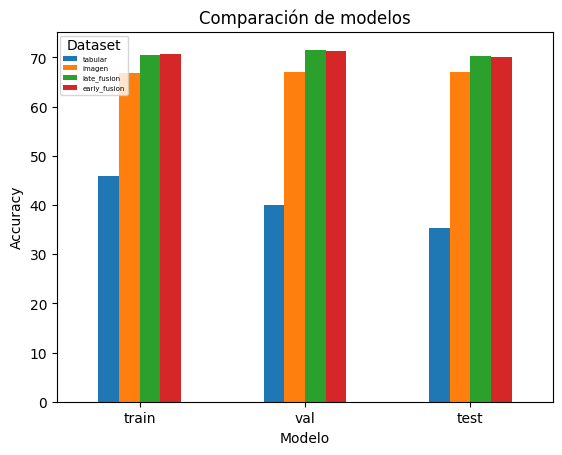

In [222]:
df.plot(kind="bar")
plt.title("Comparación de modelos")
plt.ylabel("Accuracy")
plt.xlabel("Modelo")
plt.xticks(rotation=0)
plt.legend(title="Dataset", fontsize = 5)

En este trabajo se ha abordado un problema de clasificación combinando datos tabulares e imágenes. Los resultados muestran que el modelo basado en imágenes supera claramente al modelo tabular, lo que indica que la información visual constituye la principal fuente de señal del problema.

La incorporación de técnicas de fusión multimodal (late fusion y early fusion) permite mejorar el rendimiento respecto al modelo de imagen individual, lo que confirma que los datos tabulares aportan información complementaria.

Entre las estrategias evaluadas, late fusion obtiene el mejor desempeño, mostrando mayor robustez al combinar predicciones de modelos entrenados de forma independiente. Por su parte, early fusion alcanza resultados similares, aunque requiere un mayor ajuste para aprovechar todo su potencial.

Además, la consistencia entre los resultados de entrenamiento, validación y test indica una buena capacidad de generalización y la ausencia de sobreajuste significativo.

En conclusión, el enfoque multimodal mejora el rendimiento del sistema, siendo late fusion la estrategia más efectiva en este caso.